## 二维图像信号卷积

首先是利用自己的卷积实现对二维图像的处理

先对黑白图片进行操作

In [9]:
import cv2
import os
import numpy as np
from utils import ss_conv2d
import matplotlib.pyplot as plt

img_path = "./data/people.jpeg"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
# 把img转成numpy数组
img = np.array(img)
# print(img.shape)

kernel1 = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]],)   # 垂直边缘
kernel2 = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])   # 水平边缘
kernel3 = np.array([[-1, -1, -1],
                    [-1, 8, -1],
                    [-1, -1, -1]])  # 边缘
kernel4 = np.array([[1, 1, 1],
                    [1, 1, 1],
                    [1, 1, 1]]) * 1/9  # 均值模糊
kernel5 = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]])    # 锐化
kernel6 = np.array([[-2, -1, 0],
                    [-1, 1, 1],
                    [0, 1, 2]])    # 浮雕
kernel7 = np.array([[1, 1, 1],
                    [0, 0, 0],
                    [0, 0, 0]]) * 1/3    # 拖影
kernel8 = np.array([[1, 2, 1],
                    [2, 4, 2],
                    [1, 2, 1]]) * 1/16  # 高斯滤波

img_with_color_path = 'data/fox.jpg'
img_with_color = cv2.imread(img_with_color_path, cv2.IMREAD_COLOR_BGR)
img_with_color = np.array(img_with_color)
print(img_with_color.shape)


(1200, 1920, 3)


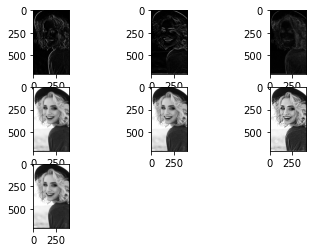

In [2]:
# 卷积
out1 = ss_conv2d(img, kernel1).clip(0, 255).astype(np.uint8)
out2 = ss_conv2d(img, kernel2).clip(0, 255).astype(np.uint8)
out3 = ss_conv2d(img, kernel3).clip(0, 255).astype(np.uint8)
out4 = ss_conv2d(img, kernel4).clip(0, 255).astype(np.uint8)
out5 = ss_conv2d(img, kernel5).clip(0, 255).astype(np.uint8)
out6 = ss_conv2d(img, kernel6).clip(0, 255).astype(np.uint8)
out7 = ss_conv2d(img, kernel7).clip(0, 255).astype(np.uint8)

# 保存结果
save_path = "./result"
os.makedirs(save_path, exist_ok=True)
cv2.imwrite(os.path.join(save_path, "ground_truth.png"), img)
cv2.imwrite(os.path.join(save_path, "out1.png"), out1)
cv2.imwrite(os.path.join(save_path, "out2.png"), out2)
cv2.imwrite(os.path.join(save_path, "out3.png"), out3)
cv2.imwrite(os.path.join(save_path, "out4.png"), out4)
cv2.imwrite(os.path.join(save_path, "out5.png"), out5)
cv2.imwrite(os.path.join(save_path, "out6.png"), out6)
cv2.imwrite(os.path.join(save_path, "out7.png"), out7)

# 可视化结果
plt.subplot(3, 3, 1)
plt.imshow(out1, cmap='gray')
plt.subplot(3, 3, 2)
plt.imshow(out2, cmap='gray')
plt.subplot(3, 3, 3)
plt.imshow(out3, cmap='gray')
plt.subplot(3, 3, 4)
plt.imshow(out4, cmap='gray')
plt.subplot(3, 3, 5)
plt.imshow(out5, cmap='gray')
plt.subplot(3, 3, 6)
plt.imshow(out6, cmap='gray')
plt.subplot(3, 3, 7)
plt.imshow(out7, cmap='gray')
plt.show()

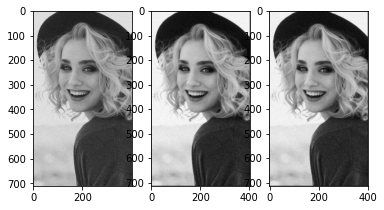

In [11]:
# 加噪和去噪
noise = np.random.normal(-10, 10, img.shape)
noised_img = img + noise
denoised_img = ss_conv2d(noised_img, kernel4)
gaussian_denoised_img = ss_conv2d(noised_img, kernel8)

plt.subplot(1, 3, 1)
plt.imshow(noised_img, cmap='gray')
plt.imsave('result/noised_img.png', noised_img, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(denoised_img, cmap='gray')
plt.imsave('result/denoised_img.png', denoised_img, cmap='gray')
plt.subplot(1, 3, 3)
plt.imshow(gaussian_denoised_img, cmap='gray')
plt.imsave('result/gaussian_denoised_img.png', gaussian_denoised_img, cmap='gray')
plt.show()

然后我们对一张三通道的彩色图片进行depthwise的convolution

(1200, 1920, 3)


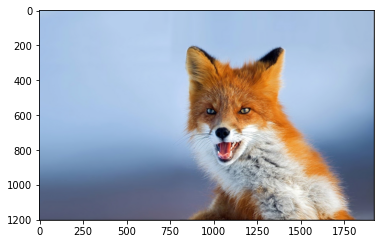

In [ ]:
temp0 = ss_conv2d(img_with_color[:, :, 0], kernel4).clip(0, 255).astype(np.uint8)
temp1 = ss_conv2d(img_with_color[:, :, 1], kernel4).clip(0, 255).astype(np.uint8)
temp2 = ss_conv2d(img_with_color[:, :, 2], kernel4).clip(0, 255).astype(np.uint8)
output = np.stack([temp0, temp1, temp2], axis=2)

cv2.imwrite(os.path.join(save_path, "out_with_color_blur.png"), output)

output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.imshow(output)
plt.show()

下面基于pytorch实现对黑白图片以及彩色图片的卷积

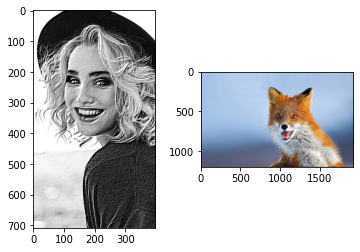

In [25]:
import torch
import torch.nn.functional as F

img_without_color = torch.tensor(img, dtype=torch.float32).unsqueeze(dim=2).permute(2, 0, 1).unsqueeze(0)   # (:, :, 1) -> (1, 1, :, :)
img_with_color = torch.tensor(img_with_color, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)   # (:, :, 3) -> (1, 3, :, :)

kernel_without_color = torch.tensor(kernel6, dtype=torch.float32).view(1, 1, 3, 3)   # (1, 1, 3, 3)
kernel_with_color = torch.tensor(kernel6, dtype=torch.float32).unsqueeze(0).expand(3, -1, -1).view(3, 1, 3, 3)   # (3, 1, 3, 3)

out_without_color = F.conv2d(img_without_color, kernel_without_color, stride=1)
out_with_color = F.conv2d(img_with_color, kernel_with_color, stride=1, groups=3)

out_without_color = out_without_color.squeeze(0).permute(1, 2, 0).numpy().clip(0, 255).astype(np.uint8)
out_with_color = out_with_color.squeeze(0).permute(1, 2, 0).numpy().clip(0, 255).astype(np.uint8)

cv2.imwrite(os.path.join(save_path, "out_without_color_torch.png"), out_without_color)
cv2.imwrite(os.path.join(save_path, "out_with_color_torch.png"), out_with_color)

plt.subplot(1, 2, 1)
plt.imshow(out_without_color, cmap='gray')
plt.subplot(1, 2, 2)
out_with_color = cv2.cvtColor(out_with_color, cv2.COLOR_BGR2RGB)
plt.imshow(out_with_color)
plt.show()
